# Pillow

[Pillow](https://pillow.readthedocs.io/en/stable/) &mdash; бібліотека для роботи з зображеннями. 
Нащадок проєкту PIL. Проєкт PIL сьогодні не пдтримується.

Встановлення pillow: 
<br>
<code>pip install pillow</code>

Використання pillow:
<br>
<code>import PIL</code>


In [11]:
from PIL import Image
from pathlib import Path

import PIL, sys
print(f'PIL {PIL.__version__}')

PIL 12.1.0


In [12]:
root = Path('.')
pictures = root.joinpath('data')
pict1 = pictures.joinpath('sample01.jpg')
pict2 = pictures.joinpath('sample02.png')

[<code>Image.open(...)</code>](https://pillow.readthedocs.io/en/stable/reference/Image.html#PIL.Image.open) відкриття графічного файлу
<br>
<code>Image.size</code> &mdash; кортеж розмірностей (ширина, висота)
<br>
[<code>Image.getpixel((i, j))</code>](https://pillow.readthedocs.io/en/stable/reference/Image.html#PIL.Image.Image.getpixel) &mdash; значення пікселя
<br>
[<code>Image.putpixel((i, j), value)</code>](https://pillow.readthedocs.io/en/stable/reference/Image.html#PIL.Image.Image.putpixel) &mdash; встановлює значення пікселя

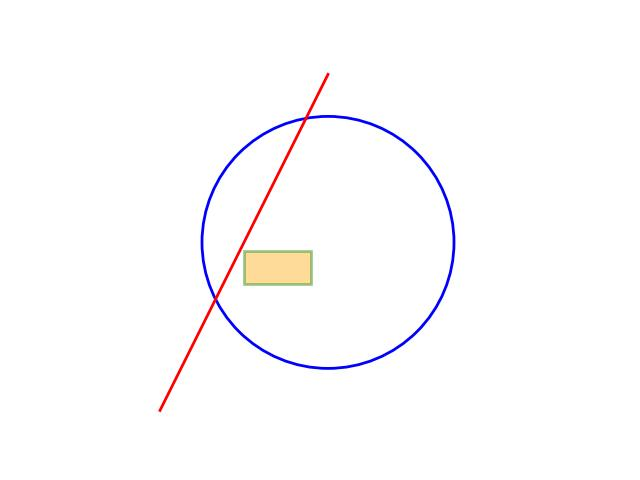

In [13]:
im = Image.open(pict1)
im

In [4]:
im.size

(640, 480)

[<code>Image.getbbox()</code>](https://pillow.readthedocs.io/en/stable/reference/Image.html#PIL.Image.Image.getbbox) &mdash; обмежуюча рамка (bounding box)

Бокс задається як четвірка координат: лівий кут, верхній кут, правий кут, нижній кут.

In [4]:
im.getbbox()

(0, 0, 640, 480)

Бокс визначає заповнену частину зображення, але біла частина для нього теж заповнена. Бувають ситуації, коли у зображення треба обрізати білі береги.

In [5]:
BLANK_PNG = (255, 255, 255, 255)
BLANK_JPG = (255, 255, 255)

In [14]:
def blank(pixel):
    return all(el == 255 for el in pixel)

def blank_line(im, line):
    return all(blank(im.getpixel((i, line))) for i in range(im.size[0]))

def blank_col(im, col):
    return all(blank(im.getpixel((col, i))) for i in range(im.size[1]))

def first(im):
    line = 0
    while line < im.size[1] and blank_line(im, line):
        line += 1
    return line

def last(im):
    line = im.size[1] - 1
    while line >= 0 and blank_line(im, line):
        line -= 1
    return line

def left(im):
    col = 0
    while col < im.size[0] and blank_col(im, col):
        col += 1
    return col

def right(im):
    col = im.size[0] - 1
    while col >= 0 and blank_col(im, col):
        col -= 1
    return col

def getbbox(im):
    return (max(0, left(im) - 1), max(0, first(im) - 1), right(im) + 1, last(im) + 1)

In [15]:
getbbox(im)

(142, 62, 465, 417)

Небіла частина зображення суттєво менша, ніж обмежена рамкою.

[<code>Image.crop(box)</code>](https://pillow.readthedocs.io/en/stable/reference/Image.html#PIL.Image.Image.crop) &mdash; обрізає зображення
<br>
[<code>Image.save(...)</code>](https://pillow.readthedocs.io/en/stable/reference/Image.html#PIL.Image.Image.save) &mdash; зберігає зображення

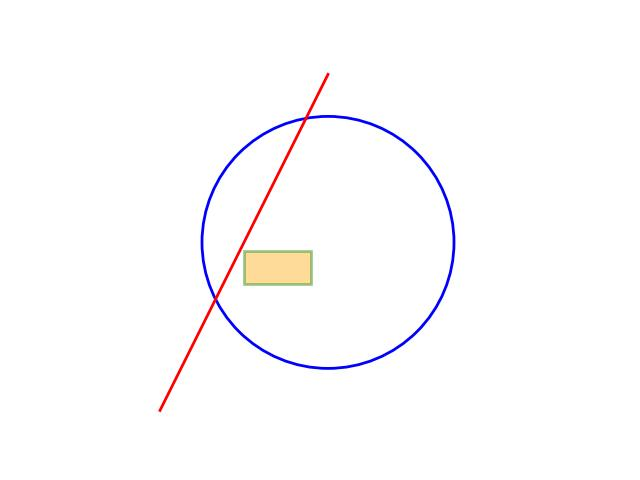

In [16]:
im

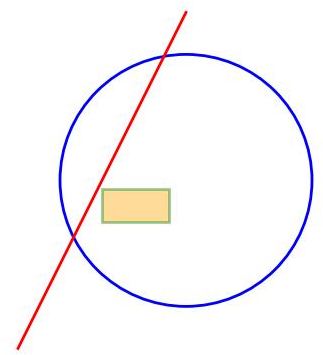

In [17]:
im.crop(getbbox(im))

In [21]:
def process(path: Path):
    with Image.open(path) as im:
        print(path.name, end=' ')
        print(im.getbbox(), end=' ')
        box = getbbox(im)
        print(box, end=' ')
        newname = path.with_name(path.stem+'_trimmed'+path.suffix)
        print(newname.name)
        im = im.crop(box)
        im.save(newname)

In [20]:
process(pict1)
process(pict2)

sample01.jpg (0, 0, 640, 480) (142, 62, 465, 417) sample01_trimmed.jpg
sample02.png (0, 0, 640, 480) (100, 237, 268, 459) sample02_trimmed.png
